# Advise Management and Interpret a Severe Price Event

**Inputs:** the validated cost-accounting outputs from `03_Costs.ipynb`.

- **Stage 6:** compare UNHEDGED, COARSE_CAL, and GRANULAR using cost and risk evidence;
- **Stage 7:** identify and interpret the most severe realised 2024 Day-Ahead price event.

The analysis keeps the ex-ante hedge-design decision separate from the ex-post 2024 backtest.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from IPython.display import display

In [2]:
results_dir = Path('../Results')
results_dir.mkdir(parents=True, exist_ok=True)

expected_rows = 35136

stage5_summary = pd.read_csv(results_dir / '03_stage5_imbalance_summary.csv')
cost_data = pd.read_csv(results_dir / '03_cost_timeseries.csv')

cost_data['timestamp_utc'] = pd.to_datetime(cost_data['timestamp_utc'], utc=True)
cost_data['timestamp_local'] = pd.to_datetime(cost_data['timestamp_local'], utc=True).dt.tz_convert('Europe/Berlin')

assert len(cost_data) == expected_rows
assert cost_data.isna().sum().sum() == 0

display(stage5_summary.round(4))

,Strategy,Forecast Cost EUR,Imbalance Settlement EUR,Imbalance Premium EUR,Final Cost EUR,Final Financial Representation EUR,Reconciliation Error EUR,Actual Annual MWh,Average Procurement Price EUR/MWh,Saving vs UNHEDGED EUR
0,UNHEDGED,3.506704e+06,30503.8398,13589.2439,3.537208e+06,3.537208e+06,-0.0,43138.0,81.9975,0.0000
1,COARSE_CAL,3.450967e+06,30503.8398,13589.2439,3.481470e+06,3.481470e+06,-0.0,43138.0,80.7054,55737.3475
2,GRANULAR,3.451507e+06,30503.8398,13589.2439,3.482011e+06,3.482011e+06,-0.0,43138.0,80.7180,55196.6469


## Stage 6 - Advise management

The three strategies are compared using:

- final annual procurement cost;
- average procurement price of actual load;
- saving versus UNHEDGED;
- monthly procurement-price standard deviation;
- monthly price range;
- absolute residual Day-Ahead volume;
- residual-load RMSE;
- imbalance settlement and imbalance premium.

The realised 2024 cost metrics are **backtest outcomes**. They were not known when the hedge was selected on 29 September 2023.

In [3]:
strategy_columns = {
    'UNHEDGED': {
        'futures': 'futures_cost_unhedged_eur',
        'residual_cost': 'residual_da_cost_unhedged_eur',
        'residual': 'residual_unhedged_mwh'
    },
    'COARSE_CAL': {
        'futures': 'futures_cost_coarse_eur',
        'residual_cost': 'residual_da_cost_coarse_cal_eur',
        'residual': 'residual_coarse_cal_mwh'
    },
    'GRANULAR': {
        'futures': 'futures_cost_granular_eur',
        'residual_cost': 'residual_da_cost_granular_eur',
        'residual': 'residual_granular_mwh'
    }
}

for strategy, cols in strategy_columns.items():
    cost_data[f'final_cost_{strategy.lower()}_eur'] = (
        cost_data[cols['futures']]
        + cost_data[cols['residual_cost']]
        + cost_data['imbalance_settlement_eur']
    )

interval_final_costs = pd.DataFrame({
    'Strategy': list(strategy_columns),
    'Final Cost EUR': [
        cost_data[f'final_cost_{strategy.lower()}_eur'].sum()
        for strategy in strategy_columns
    ]
})

display(interval_final_costs.round(2))

,Strategy,Final Cost EUR
0,UNHEDGED,3537207.83
1,COARSE_CAL,3481470.48
2,GRANULAR,3482011.18


### Monthly procurement-price comparison

Monthly average procurement price is calculated as total monthly procurement cost divided by realised monthly customer load. Its standard deviation and range provide descriptive measures of cost stability and seasonal exposure.

In [4]:
cost_data['month'] = cost_data['timestamp_local'].dt.month

monthly = cost_data.groupby('month').agg(
    actual_mwh=('total_actual_mwh', 'sum'),
    unhedged_cost=('final_cost_unhedged_eur', 'sum'),
    coarse_cost=('final_cost_coarse_cal_eur', 'sum'),
    granular_cost=('final_cost_granular_eur', 'sum')
)

monthly_prices = pd.DataFrame(index=monthly.index)
monthly_prices['UNHEDGED'] = monthly['unhedged_cost'] / monthly['actual_mwh']
monthly_prices['COARSE_CAL'] = monthly['coarse_cost'] / monthly['actual_mwh']
monthly_prices['GRANULAR'] = monthly['granular_cost'] / monthly['actual_mwh']

monthly_prices.index.name = 'Month'
display(monthly_prices.round(2))

monthly_std = monthly_prices.std()
monthly_range = monthly_prices.max() - monthly_prices.min()

stability_summary = pd.DataFrame({
    'Monthly Price Std Dev EUR/MWh': monthly_std,
    'Monthly Price Range EUR/MWh': monthly_range
})

display(stability_summary.round(2))

,UNHEDGED,COARSE_CAL,GRANULAR
Month,,,
1,81.39,81.51,80.11
2,64.88,79.04,63.62
3,66.60,78.44,65.36
4,63.29,79.29,66.15
5,66.42,80.55,66.29
6,74.49,80.97,67.30
7,66.94,81.74,74.88
8,79.92,77.41,72.95
9,78.91,78.49,74.24


,Monthly Price Std Dev EUR/MWh,Monthly Price Range EUR/MWh
UNHEDGED,20.15,58.43
COARSE_CAL,2.43,9.08
GRANULAR,18.56,47.08


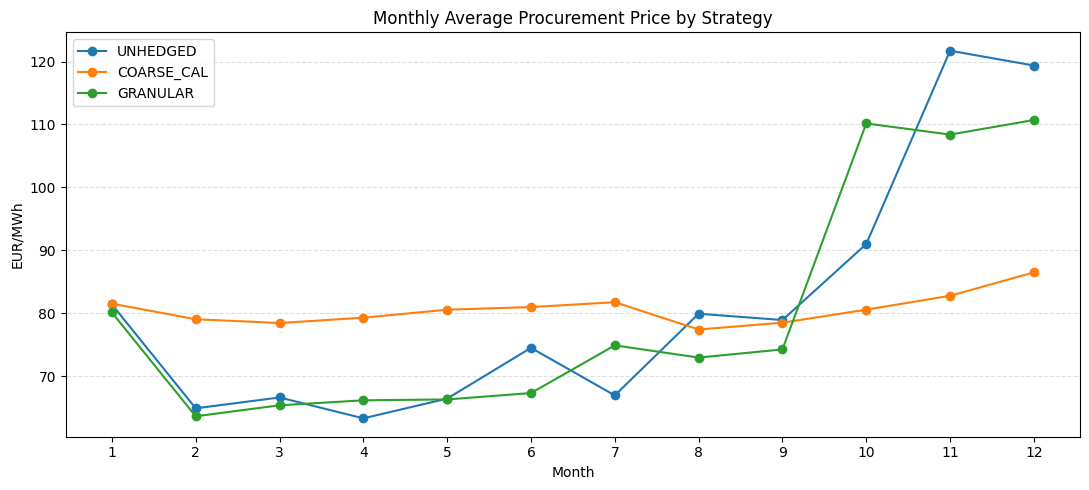

In [5]:
ax = monthly_prices.plot(marker='o', figsize=(11, 5))
ax.set_title('Monthly Average Procurement Price by Strategy')
ax.set_xlabel('Month')
ax.set_ylabel('EUR/MWh')
ax.set_xticks(range(1, 13))
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(results_dir / '04 Monthly Procurement Price Comparison.png', dpi=144, transparent=True)
plt.show()

### Final cost-and-risk comparison

This table combines realised procurement outcomes with the hedge-shape metrics. Lower residual volume and RMSE indicate a closer physical match to the forecast load; lower monthly price dispersion indicates greater realised cost stability.

In [6]:
stage5 = stage5_summary.set_index('Strategy')

comparison_rows = []

for strategy in ['UNHEDGED', 'COARSE_CAL', 'GRANULAR']:
    residual = cost_data[strategy_columns[strategy]['residual']]
    comparison_rows.append({
        'Strategy': strategy,
        'Final Annual Cost EUR': stage5.loc[strategy, 'Final Cost EUR'],
        'Average Procurement Price EUR/MWh': stage5.loc[strategy, 'Average Procurement Price EUR/MWh'],
        'Saving vs UNHEDGED EUR': stage5.loc[strategy, 'Saving vs UNHEDGED EUR'],
        'Monthly Price Std Dev EUR/MWh': monthly_std[strategy],
        'Monthly Price Range EUR/MWh': monthly_range[strategy],
        'Absolute Residual DA Volume MWh': residual.abs().sum(),
        'Residual-Load RMSE MWh': np.sqrt(np.mean(residual ** 2)),
        'Imbalance Settlement EUR': stage5.loc[strategy, 'Imbalance Settlement EUR'],
        'Imbalance Premium EUR': stage5.loc[strategy, 'Imbalance Premium EUR']
    })

cost_risk_comparison = pd.DataFrame(comparison_rows)

display(cost_risk_comparison.round(2))

cost_risk_comparison.to_csv(
    results_dir / '04_cost_risk_comparison.csv',
    index=False
)

monthly_prices.to_csv(
    results_dir / '04_monthly_procurement_prices.csv'
)

,Strategy,Final Annual Cost EUR,Average Procurement Price EUR/MWh,Saving vs UNHEDGED EUR,Monthly Price Std Dev EUR/MWh,Monthly Price Range EUR/MWh,Absolute Residual DA Volume MWh,Residual-Load RMSE MWh,Imbalance Settlement EUR,Imbalance Premium EUR
0,UNHEDGED,3537207.83,82.00,0.00,20.15,58.43,43000.00,1.32,30503.84,13589.24
1,COARSE_CAL,3481470.48,80.71,55737.35,2.43,9.08,12760.13,0.44,30503.84,13589.24
2,GRANULAR,3482011.18,80.72,55196.65,18.56,47.08,11985.15,0.42,30503.84,13589.24


### Ex-ante versus ex-post interpretation

**Ex ante (29 September 2023):** the GRANULAR hedge gives the closer match to forecast load because it uses finer non-overlapping delivery blocks. It therefore has lower residual Day-Ahead volume and lower residual-load RMSE.

**Ex post (2024 backtest):** COARSE_CAL produces a slightly lower realised annual procurement cost and much lower month-to-month procurement-price dispersion.

The realised advantage of COARSE_CAL was not known when the hedge was designed. The backtest therefore evaluates how the strategies performed under the realised 2024 price path rather than proving that one strategy was unconditionally superior ex ante.

In [7]:
coarse_row = cost_risk_comparison.set_index('Strategy').loc['COARSE_CAL']
granular_row = cost_risk_comparison.set_index('Strategy').loc['GRANULAR']

ex_ante_ex_post = pd.DataFrame([
    {
        'Perspective': 'Ex ante hedge design',
        'Evidence': 'Residual DA volume / residual-load RMSE',
        'COARSE_CAL': f"{coarse_row['Absolute Residual DA Volume MWh']:.2f} MWh / {coarse_row['Residual-Load RMSE MWh']:.4f} MWh",
        'GRANULAR': f"{granular_row['Absolute Residual DA Volume MWh']:.2f} MWh / {granular_row['Residual-Load RMSE MWh']:.4f} MWh",
        'Interpretation': 'GRANULAR matches forecast load more closely'
    },
    {
        'Perspective': 'Ex post 2024 backtest',
        'Evidence': 'Final cost / monthly price standard deviation',
        'COARSE_CAL': f"EUR {coarse_row['Final Annual Cost EUR']:,.2f} / {coarse_row['Monthly Price Std Dev EUR/MWh']:.2f} EUR/MWh",
        'GRANULAR': f"EUR {granular_row['Final Annual Cost EUR']:,.2f} / {granular_row['Monthly Price Std Dev EUR/MWh']:.2f} EUR/MWh",
        'Interpretation': 'COARSE_CAL realised lower cost and greater cost stability'
    }
])

display(ex_ante_ex_post)

ex_ante_ex_post.to_csv(
    results_dir / '04_ex_ante_ex_post_summary.csv',
    index=False
)

,Perspective,Evidence,COARSE_CAL,GRANULAR,Interpretation
0,Ex ante hedge design,Residual DA volume / residual-load RMSE,12760.13 MWh / 0.4417 MWh,11985.15 MWh / 0.4213 MWh,GRANULAR matches forecast load more closely
1,Ex post 2024 backtest,Final cost / monthly price standard deviation,"EUR 3,481,470.48 / 2.43 EUR/MWh","EUR 3,482,011.18 / 18.56 EUR/MWh",COARSE_CAL realised lower cost and greater cos...


### Management interpretation

For the **observed 2024 backtest**, COARSE_CAL provides the strongest realised cost stability and a marginally lower annual procurement cost. GRANULAR, however, remains the better **ex-ante hedge-shape** solution.


> **COARSE_CAL is the preferred strategy on the realised 2024 cost-and-stability evidence, but GRANULAR was superior on the ex-ante shape-matching objective.**

The recommendation should not be interpreted as evidence that the annual hedge was known in advance to outperform under the realised 2024 price path.

## Stage 7 - Interpret a severe price event

The severe-price event is selected mechanically as the interval with the highest realised 2024 Day-Ahead price.

The event analysis compares:

- realised Day-Ahead price;
- forecast and actual customer load;
- hedge energy;
- residual Day-Ahead exposure;
- residual Day-Ahead cost.


In [8]:
event_index = cost_data['day_ahead_price_eur_mwh'].idxmax()
event = cost_data.loc[event_index]

event_timestamp = event['timestamp_local']
event_date = event_timestamp.date()

print('Selected event:', event_timestamp)
print('Day-Ahead price (EUR/MWh):', round(event['day_ahead_price_eur_mwh'], 2))
print('Forecast load (MWh):', round(event['forecast_mwh'], 4))
print('Actual load (MWh):', round(event['total_actual_mwh'], 4))
print('Imbalance (MWh):', round(event['imbalance_mwh'], 4))
print('reBAP (EUR/MWh):', round(event['imbalance_price_eur_mwh'], 2))

Selected event: 2024-12-12 17:00:00+01:00
Day-Ahead price (EUR/MWh): 936.28
Forecast load (MWh): 1.589
Actual load (MWh): 1.6778
Imbalance (MWh): 0.0888
reBAP (EUR/MWh): 90.05


In [9]:
event_rows = []

event_mapping = {
    'UNHEDGED': ('hedge_unhedged_mwh', 'residual_unhedged_mwh', 'residual_da_cost_unhedged_eur'),
    'COARSE_CAL': ('hedge_coarse_mwh', 'residual_coarse_cal_mwh', 'residual_da_cost_coarse_cal_eur'),
    'GRANULAR': ('hedge_granular_mwh', 'residual_granular_mwh', 'residual_da_cost_granular_eur')
}

for strategy, (hedge_col, residual_col, residual_cost_col) in event_mapping.items():
    event_rows.append({
        'Strategy': strategy,
        'Timestamp Local': event_timestamp,
        'Day-Ahead Price EUR/MWh': event['day_ahead_price_eur_mwh'],
        'Forecast Load MWh': event['forecast_mwh'],
        'Actual Load MWh': event['total_actual_mwh'],
        'Hedge MWh': event[hedge_col],
        'Residual DA MWh': event[residual_col],
        'Residual DA Cost EUR': event[residual_cost_col],
        'Imbalance MWh': event['imbalance_mwh'],
        'reBAP EUR/MWh': event['imbalance_price_eur_mwh']
    })

severe_event = pd.DataFrame(event_rows)

display(severe_event.round(4))

severe_event.to_csv(
    results_dir / '04_severe_price_event.csv',
    index=False
)

C:\Users\user\AppData\Local\Temp\ipykernel_7436\2224280390.py:25: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(severe_event.round(4))


,Strategy,Timestamp Local,Day-Ahead Price EUR/MWh,Forecast Load MWh,Actual Load MWh,Hedge MWh,Residual DA MWh,Residual DA Cost EUR,Imbalance MWh,reBAP EUR/MWh
0,UNHEDGED,2024-12-12 17:00:00+01:00,936.28,1.589,1.6778,0.0000,1.5890,1487.7536,0.0888,90.05
1,COARSE_CAL,2024-12-12 17:00:00+01:00,936.28,1.589,1.6778,1.5691,0.0199,18.6313,0.0888,90.05
2,GRANULAR,2024-12-12 17:00:00+01:00,936.28,1.589,1.6778,1.6977,-0.1087,-101.8102,0.0888,90.05


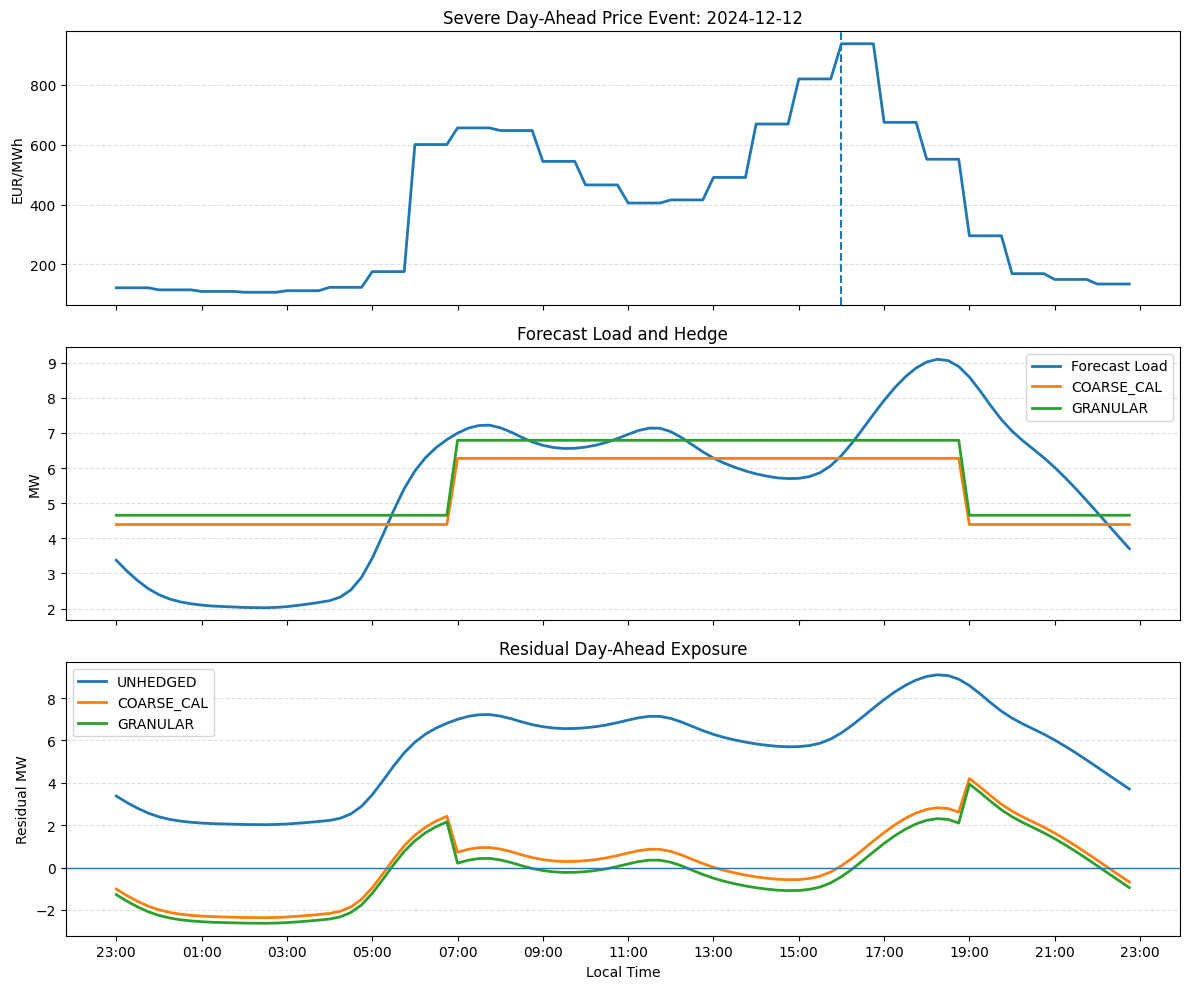

In [10]:
event_day = cost_data[
    cost_data['timestamp_local'].dt.date == event_date
].copy()

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(event_day['timestamp_local'], event_day['day_ahead_price_eur_mwh'], linewidth=2)
axes[0].axvline(event_timestamp, linestyle='--')
axes[0].set_ylabel('EUR/MWh')
axes[0].set_title(f'Severe Day-Ahead Price Event: {event_date}')
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

axes[1].plot(event_day['timestamp_local'], event_day['forecast_mwh'] / 0.25, linewidth=2, label='Forecast Load')
axes[1].plot(event_day['timestamp_local'], event_day['hedge_coarse_mwh'] / 0.25, linewidth=2, label='COARSE_CAL')
axes[1].plot(event_day['timestamp_local'], event_day['hedge_granular_mwh'] / 0.25, linewidth=2, label='GRANULAR')
axes[1].set_ylabel('MW')
axes[1].set_title('Forecast Load and Hedge')
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

axes[2].plot(event_day['timestamp_local'], event_day['residual_unhedged_mwh'] / 0.25, linewidth=2, label='UNHEDGED')
axes[2].plot(event_day['timestamp_local'], event_day['residual_coarse_cal_mwh'] / 0.25, linewidth=2, label='COARSE_CAL')
axes[2].plot(event_day['timestamp_local'], event_day['residual_granular_mwh'] / 0.25, linewidth=2, label='GRANULAR')
axes[2].axhline(0, linewidth=1)
axes[2].set_ylabel('Residual MW')
axes[2].set_xlabel('Local Time')
axes[2].set_title('Residual Day-Ahead Exposure')
axes[2].legend()
axes[2].grid(axis='y', linestyle='--', alpha=0.4)

axes[2].xaxis.set_major_locator(mdates.HourLocator(interval=2))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.tight_layout()
plt.savefig(results_dir / '04 Severe Price Event.png', dpi=144, transparent=True)
plt.show()

### Severe-event interpretation

At the selected high-price interval, the UNHEDGED strategy leaves the full forecast load exposed to the Day-Ahead price. Both hedged strategies reduce that spot exposure because only the residual \(L_t-H_t\) remains economically exposed Day-Ahead.

The event illustrates why hedging can protect liquidity during wholesale-price spikes. However:

- futures do not remove forecast error \(A_t-L_t\);
- imbalance settlement remains exposed to reBAP;
- standard Base/Peak products retain shape risk;
- a single expensive interval does not by itself imply insolvency or bankruptcy.

The severity of a price event depends on both the price level and the amount/duration of residual exposure.

## Validation and saved outputs

In [11]:
stage5_indexed = stage5_summary.set_index('Strategy')

cost_reconciliation_error = max(
    abs(
        cost_data[f'final_cost_{strategy.lower()}_eur'].sum()
        - stage5_indexed.loc[strategy, 'Final Cost EUR']
    )
    for strategy in strategy_columns
)

output_files = [
    '04_cost_risk_comparison.csv',
    '04_monthly_procurement_prices.csv',
    '04_ex_ante_ex_post_summary.csv',
    '04_severe_price_event.csv',
    '04 Monthly Procurement Price Comparison.png',
    '04 Severe Price Event.png'
]

advice_checks = pd.DataFrame([
    {
        'Check': 'Aligned quarter-hour rows',
        'Observed': len(cost_data),
        'Expected': expected_rows,
        'Passed': len(cost_data) == expected_rows
    },
    {
        'Check': 'Interval final costs reconcile to Stage 5 summary',
        'Observed': cost_reconciliation_error,
        'Expected': '< 1e-6 EUR',
        'Passed': cost_reconciliation_error < 1e-6
    },
    {
        'Check': 'Monthly procurement prices available for all 12 months',
        'Observed': len(monthly_prices),
        'Expected': 12,
        'Passed': len(monthly_prices) == 12
    },
    {
        'Check': 'Severe event is annual Day-Ahead maximum',
        'Observed': event['day_ahead_price_eur_mwh'],
        'Expected': cost_data['day_ahead_price_eur_mwh'].max(),
        'Passed': np.isclose(
            event['day_ahead_price_eur_mwh'],
            cost_data['day_ahead_price_eur_mwh'].max()
        )
    },
    {
        'Check': 'All Results outputs exist',
        'Observed': sum((results_dir / name).exists() for name in output_files),
        'Expected': len(output_files),
        'Passed': all((results_dir / name).exists() for name in output_files)
    }
])

advice_checks.to_csv(results_dir / '04_advice_checks.csv', index=False)

assert advice_checks['Passed'].all()

display(advice_checks)
print(f"{advice_checks['Passed'].sum()} of {len(advice_checks)} checks passed")

,Check,Observed,Expected,Passed
0,Aligned quarter-hour rows,3.513600e+04,35136,True
1,Interval final costs reconcile to Stage 5 summary,4.656613e-10,< 1e-6 EUR,True
2,Monthly procurement prices available for all 1...,1.200000e+01,12,True
3,Severe event is annual Day-Ahead maximum,9.362800e+02,936.28,True
4,All Results outputs exist,6.000000e+00,6,True


5 of 5 checks passed


### Closing interpretation

- **Ex ante:** GRANULAR provides the closer forecast-load match.
- **Ex post:** COARSE_CAL realises slightly lower annual cost and substantially lower monthly procurement-price dispersion in 2024.
- **Volume risk remains:** imbalance settlement is unaffected by the futures strategy because the same forecast load is scheduled Day-Ahead.
- **Severe-price events matter through residual exposure:** the hedge reduces, but does not eliminate, exposure to extreme spot prices.